<a href="https://colab.research.google.com/github/2003UJAN/Laryngeal-Cancer-Few-Shot-Learning-XAI/blob/main/Laryngeal_Cancer_XAI_Resnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pytorch_metric_learning

  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl.metadata (1.8 kB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-manylinu

In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 19.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.2-py3-none-any.whl size=38334 sha256=5963de1bf80695b3b4f8ac718d5370302296ad3c251ced4e7ca874334d4fde1a
  Stored in directory: /root/.cache/pip/wheels/b4/68/bb/d10381e86dc0de1c9354bce3d86bffcd247305058c40ce2e55
Successfully built grad-cam


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
from pytorch_metric_learning import losses
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt
from torchvision.models import resnet18
import zipfile
import os

In [ ]:
zip_path = 'archive.zip'
extract_path = '.'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

dataset_path = os.path.join(extract_path, 'laryngeal dataset', 'laryngeal dataset')

In [ ]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((100, 100)),
    transforms.ToTensor()
])

In [ ]:
def load_dataset(root_path, transform):
    return datasets.ImageFolder(root=root_path, transform=transform)

In [ ]:
fold1_path = os.path.join(dataset_path, 'FOLD 1')
fold2_path = os.path.join(dataset_path, 'FOLD 2')
fold3_path = os.path.join(dataset_path, 'FOLD 3')

In [ ]:
train_data = load_dataset(fold1_path, transform)
val_data = load_dataset(fold2_path, transform)
test_data = load_dataset(fold3_path, transform)

In [ ]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [ ]:
class PrototypicalNetwork(nn.Module):
    def __init__(self, embedding_dim, num_classes):
        super(PrototypicalNetwork, self).__init__()
        self.resnet = resnet18(pretrained=True)
        self.resnet.conv1 = nn.Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        self.resnet.fc = nn.Linear(self.resnet.fc.in_features, embedding_dim)
        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, x):
        embeddings = self.resnet(x)
        logits = self.classifier(embeddings)
        return logits

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
embedding_dim = 64
num_classes = len(train_data.classes)
model = PrototypicalNetwork(embedding_dim, num_classes).to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.7)
criterion = nn.CrossEntropyLoss()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 110MB/s]


In [ ]:
def compute_accuracy(loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            predictions = torch.argmax(logits, dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
    return correct / total

for epoch in range(40):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    scheduler.step()
    train_acc = compute_accuracy(train_loader)
    val_acc = compute_accuracy(val_loader)

    print(f'Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}, '
          f'Train Accuracy: {train_acc*100:.2f}%, Val Accuracy: {val_acc*100:.2f}%')

test_acc = compute_accuracy(test_loader)
print(f'Test Accuracy: {test_acc*100:.2f}%')

Epoch 1, Loss: 0.8365741925580161, Train Accuracy: 29.77%, Val Accuracy: 25.23%
Epoch 2, Loss: 0.5667796518121447, Train Accuracy: 47.95%, Val Accuracy: 39.77%
Epoch 3, Loss: 0.3402638648237501, Train Accuracy: 33.18%, Val Accuracy: 30.23%
Epoch 4, Loss: 0.27904142279710087, Train Accuracy: 89.77%, Val Accuracy: 77.73%
Epoch 5, Loss: 0.3844737410545349, Train Accuracy: 76.59%, Val Accuracy: 59.55%
Epoch 6, Loss: 0.24181469955614635, Train Accuracy: 94.32%, Val Accuracy: 82.27%
Epoch 7, Loss: 0.2264242180223976, Train Accuracy: 85.91%, Val Accuracy: 71.82%
Epoch 8, Loss: 0.17898771645767347, Train Accuracy: 85.45%, Val Accuracy: 79.09%
Epoch 9, Loss: 0.16883570501314743, Train Accuracy: 81.14%, Val Accuracy: 78.18%
Epoch 10, Loss: 0.12165836963270392, Train Accuracy: 88.64%, Val Accuracy: 78.86%
Epoch 11, Loss: 0.12234697198229176, Train Accuracy: 98.41%, Val Accuracy: 89.77%
Epoch 12, Loss: 0.0973600238295538, Train Accuracy: 90.23%, Val Accuracy: 77.95%
Epoch 13, Loss: 0.0890152045924

In [ ]:
def generate_gradcam(model, image, target_layer):
    if image.shape[0] != model.resnet.conv1.weight.shape[1]:
        image = image.repeat(model.resnet.conv1.weight.shape[1], 1, 1)
    cam = GradCAM(model=model, target_layers=[target_layer])
    grayscale_cam = cam(input_tensor=image.unsqueeze(0))[0, :]
    image = image.permute(1, 2, 0).cpu().numpy()
    cam_image = show_cam_on_image(image, grayscale_cam, use_rgb=True)
    return cam_image

In [ ]:
test_iter = iter(test_loader)
images, labels = next(test_iter)
image = images[0].to(device)
target_layer = model.resnet.layer4[-1]
cam_image = generate_gradcam(model, image, target_layer)

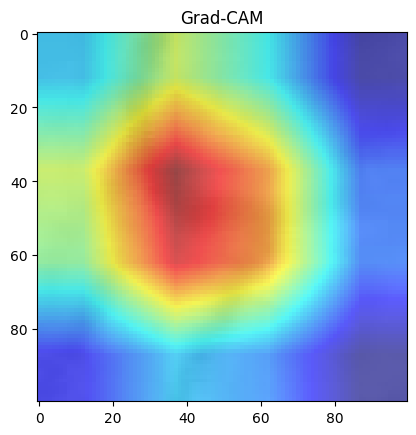

In [ ]:
plt.imshow(cam_image)
plt.title('Grad-CAM')
plt.show()